# Univariant TS, Seq2Seq
Predicts multiple future values (e.g., the next 5 time steps) instead of just the next one. Multi-output approach. (c.f. recursive approach)

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# 1. Generate synthetic univariate data (sine wave with noise)
np.random.seed(42)
time = np.arange(0, 200, 0.1)
data = np.sin(time) + 0.1 * np.random.randn(len(time))

# 2. Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

# 3. Prepare dataset for sequence-to-sequence forecasting. See below for testing
def create_sequences(series, look_back=20, n_future=5):
    X, y = [], []
    for i in range(len(series) - look_back - n_future):
        X.append(series[i : i+look_back])
        y.append(series[i+look_back : i+look_back+n_future])
    return np.array(X), np.array(y)

look_back = 20   # past time steps
n_future = 5     # number of future steps to predict

X, y = create_sequences(data_scaled, look_back, n_future)
X = X.reshape((X.shape[0], X.shape[1], 1))  # (samples, timesteps, features)
y = y.reshape((y.shape[0], y.shape[1]))     # (samples, n_future)

In [38]:
print(X.shape)
print(X[:5])
print(y.shape)
print(y[:5])

(1975, 20, 1)
[[[0.50580029]
  [0.52048595]
  [0.5921979 ]
  [0.66672035]
  [0.63365128]
  [0.67002994]
  [0.77776159]
  [0.77711387]
  [0.75668219]
  [0.82424861]
  [0.8070902 ]
  [0.82709859]
  [0.87220407]
  [0.79783514]
  [0.814296  ]
  [0.86615405]
  [0.84878465]
  [0.89922439]
  [0.84262301]
  [0.81110783]]

 [[0.52048595]
  [0.5921979 ]
  [0.66672035]
  [0.63365128]
  [0.67002994]
  [0.77776159]
  [0.77711387]
  [0.75668219]
  [0.82424861]
  [0.8070902 ]
  [0.82709859]
  [0.87220407]
  [0.79783514]
  [0.814296  ]
  [0.86615405]
  [0.84878465]
  [0.89922439]
  [0.84262301]
  [0.81110783]
  [0.91247007]]

 [[0.5921979 ]
  [0.66672035]
  [0.63365128]
  [0.67002994]
  [0.77776159]
  [0.77711387]
  [0.75668219]
  [0.82424861]
  [0.8070902 ]
  [0.82709859]
  [0.87220407]
  [0.79783514]
  [0.814296  ]
  [0.86615405]
  [0.84878465]
  [0.89922439]
  [0.84262301]
  [0.81110783]
  [0.91247007]
  [0.82548085]]

 [[0.66672035]
  [0.63365128]
  [0.67002994]
  [0.77776159]
  [0.77711387]
  [0.

In [39]:
# 4. Split into train/test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. Build LSTM model
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(look_back, 1), return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(n_future)  # predict multiple steps at once
])
model.compile(optimizer='adam', loss='mse')

# 6. Train model
model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test), verbose=0)

# 7. Forecast on test data
pred = model.predict(X_test, verbose=0)
pred_inverted = scaler.inverse_transform(pred)
y_test_inverted = scaler.inverse_transform(y_test)

# 8. RMSE
mse = np.mean(np.square(pred_inverted - y_test_inverted))
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse)}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Root Mean Squared Error (RMSE): 0.1110450539969294


(395, 5)
[[ 0.16239549  0.08439195 -0.00722752 -0.08642635 -0.19158167]
 [ 0.08042841  0.00325235 -0.08967596 -0.16869825 -0.27018794]
 [ 0.0096395  -0.06620914 -0.15902345 -0.23717622 -0.33433917]
 [-0.08035613 -0.1541587  -0.24676254 -0.32379705 -0.41572592]
 [-0.17178226 -0.24346928 -0.3354537  -0.40966028 -0.49789917]]


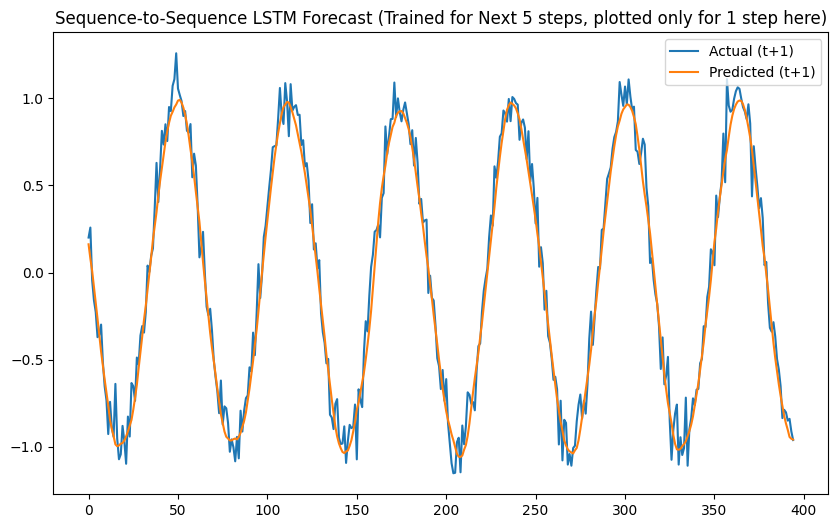

Sample index: 0
Actual Future (5 steps): [ 0.20113561  0.25841628 -0.04337268 -0.15861242 -0.22609826]
Predicted Future (5 steps): [ 0.16239549  0.08439195 -0.00722752 -0.08642635 -0.19158167]


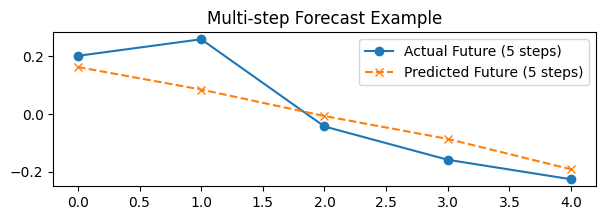

Sample index: 40
Actual Future (5 steps): [0.59735472 0.8134263  0.73479513 0.85113006 0.75473493]
Predicted Future (5 steps): [0.5260277 0.5654435 0.6667205 0.7898504 0.7945497]


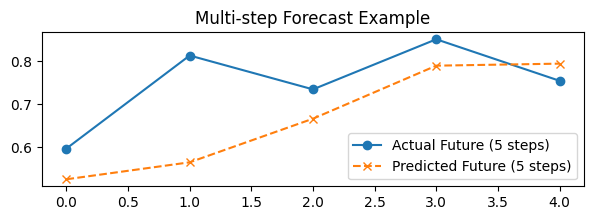

In [43]:
# 9. Visualize results
print(pred_inverted.shape)
print(pred_inverted[:5])

plt.figure(figsize=(10, 6))
plt.plot(y_test_inverted[:, 0], label='Actual (t+1)')
plt.plot(pred_inverted[:, 0], label='Predicted (t+1)')
plt.title('Sequence-to-Sequence LSTM Forecast (Trained for Next 5 steps, plotted only for 1 step here)')
plt.legend()
plt.show()

# 10. Visualize all 5-step predictions for two test samples
sample_idx = (0, 40)
for idx in sample_idx:
  print(f"Sample index: {idx}")
  print(f"Actual Future (5 steps): {y_test_inverted[idx]}")
  print(f"Predicted Future (5 steps): {pred_inverted[idx]}")

  plt.figure(figsize=(7, 2))
  plt.plot(y_test_inverted[idx], 'o-', label='Actual Future (5 steps)')
  plt.plot(pred_inverted[idx], 'x--', label='Predicted Future (5 steps)')
  plt.title('Multi-step Forecast Example')
  plt.legend()
  plt.show()

In [41]:
# to test create_sequences(series, look_back, n_future):
test_series = np.arange(12) # 0 ... 11
print(test_series)
X, y = create_sequences(test_series, look_back=5, n_future=3)
print(f"---- X\n{X}")
print(f"---- y\n{y}")
print(f"---- y[:,0]\n{y[:, 0]}")

[ 0  1  2  3  4  5  6  7  8  9 10 11]
---- X
[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]]
---- y
[[ 5  6  7]
 [ 6  7  8]
 [ 7  8  9]
 [ 8  9 10]]
---- y[:,0]
[5 6 7 8]
